In [1]:
import pandas as pd
import numpy as np
import pickle, os
from matplotlib import pyplot as plt
from tqdm import tqdm

## Read in the Omega

In [6]:
import pandas as pd

omegas_file = 'ct_data_oppc/timeomega.dat'

# Step 1: Read the column names from the line starting with "#! FIELDS"
# with open(omegas_file, 'r') as f:
#     for line in f:
#         if line.startswith('#! FIELDS'):
#             columns = line.strip().split()[2:]  # Skip '#!', 'FIELDS'
#             break

# Step 2: Use `pd.read_csv` with `skiprows`
# def skip_every_20th(start, total_lines):
#     # Skip header line, then the rest
#     return [i for i in range(start, total_lines) if i % 20 != 0]

with open(omegas_file, 'r') as f:
    # Count total lines minus comment lines
    total_rows = sum(1 for line in f if not line.startswith('#'))

# Now, use `skiprows` to skip rows directly in pandas, excluding indices for FIELDS and comments
df = pd.read_csv(
    omegas_file,
    delim_whitespace=True
#    names=columns
    #skiprows=skip_every_20th(1, total_rows)  # Start after '#! FIELDS' line
)

# Display the DataFrame
df

,time,omega1,omega2,omega3
0,0.02,2.920840,2.893603,3.097813
1,0.42,2.302964,-2.820351,2.793346
2,0.82,2.823639,-2.602560,-2.795064
3,1.22,3.056885,-2.470381,-3.033391
4,1.62,3.079291,-2.744618,-2.858711
...,...,...,...,...
2507358,988471.08,0.063649,2.961058,-0.214932
2507359,988471.10,-0.000804,2.965537,-0.319893
2507360,988471.12,-0.023433,2.960665,-0.201649
2507361,988471.14,0.092578,3.008329,-0.006666


In [7]:
# Extract the omegas 
omega_df = df[['omega1', 'omega2', 'omega3']]
# omega_df.astype(float)
omega_np = omega_df.to_numpy()
omega_np.shape

(2507363, 3)

In [8]:
# Convert the radians to angles
omega_angle = omega_np * (180 / np.pi)
omega_angle

array([[ 167.35180463,  165.79123949,  177.49161062],
       [ 131.95011757, -161.59420905,  160.04693652],
       [ 161.78259757, -149.11570393, -160.14537067],
       ...,
       [  -1.342612  ,  169.63360905,  -11.55363664],
       [   5.30432868,  172.36455509,   -0.38193367],
       [ -10.26327839, -173.56146392,   -3.40422874]])

In [9]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [10]:
def omega2cistrans(omega):
    """Converts a sequence of float omega angles (in degrees) to an array of ints: 0 cis and 1 trans."""
    
    shifted_omega = (omega + 90.0) % 360.0 - 90.0 # shift into (-90, 270) range to avoid periodic boundaries
    
    cistrans = np.where(shifted_omega > 90.0, 1, 0).astype(int)
    return cistrans

def autocorr(x):
    tau = x.size
    mu = x.mean()
    var = x.var()  # Variance for normalization
    g = np.correlate((x-mu), (x-mu), mode='full')[tau-1:]
    g = g / var
    n = np.arange(tau,0,-1)
    return g/n

all_cistrans = omega2cistrans(omega_angle)
all_cistrans.shape

<ipython-input-10-7bb5ac35fc8c>:4: RuntimeWarning: invalid value encountered in remainder
  shifted_omega = (omega + 90.0) % 360.0 - 90.0 # shift into (-90, 270) range to avoid periodic boundaries


(2507363, 3)

## Calculate the AutoCoorelation Plot

In [ ]:
# Load in the omega angles by replica
dt_in_ns = 0.002   # 1 ps per snapshot I GUESS?????
Nmax = 500 # Maximum number of steps to display in plots


# Convert list of lists to a NumPy array 
timesteps, residues = all_cistrans.shape # (49961, 3)

# Calculate autocorrelation for each replica and residue
autocorr_results = np.zeros((residues, timesteps))

for i in tqdm(range(residues), desc="Processing Residue"):
    cistrans = all_cistrans[:, i]
    autocorr_results[i, :] = autocorr(cistrans)
# After finishing the inner loop, update once

print(autocorr_results.shape)  # Should output (3, 49961)

In [ ]:
## Save the data 

os.makedirs('autocoorel_data_oppc', exist_ok=True )
data_instance = Data(autocorr_results)
data_instance.save("autocoorel_data_oppc/autocoorelation_res.pkl")

In [11]:
# To load it back later
autocorr_results = Data.load("autocoorel_data_oppc/autocoorelation_res.pkl").array_list
autocorr_results.shape

(3, 2507363)

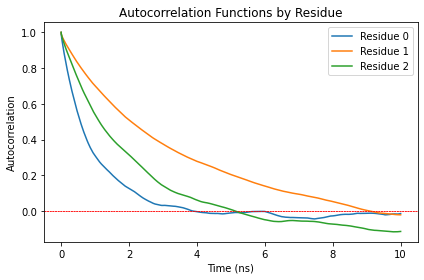

In [12]:
import numpy as np
import matplotlib.pyplot as plt

residues = [0, 1, 2]
nreplicas = 6
Nmax = 25000  # Maximum number of steps to display in plots
dt_in_ns = 0.0004  # 1 ps per step (converted to ns) YES????
tau_c_values = []

for res in residues:
    g = autocorr_results[res]
    tau_c = np.sum(g[0:Nmax])
    tau_c_values.append(tau_c * dt_in_ns)

    plt.plot(np.arange(Nmax) * dt_in_ns, g[:Nmax], label=f'Residue {res}')
    plt.axhline(0, color='r', linestyle='--', linewidth=0.5)  # Horizontal zero line

plt.xlabel('Time (ns)')
plt.ylabel('Autocorrelation')
plt.legend()
plt.title('Autocorrelation Functions by Residue')
plt.tight_layout()
plt.show()